# Data Cleaning and Pre-Processing: Sentiment140 Datensatz

### Sentiment140 Datensatz

Datensatz wurde im Rahmen der Arbeiten am Paper [Twitter Sentiment Classification using Distant Supervision][paper-zu-sentiment140-datensatz] erzeugt.

Wichtige Punkte bezüglich des verwendeten Trainings- bzw. Test-Datensatzes:

- Zu damaligem Zeitpunkt **Längenbeschränkung der Tweets auf 140 Zeichen**.
- Test- und Trainings-Datensätze enthalten **lediglich Tweets in englischer Sprache** (Kennzeichen wurde bei Verwendung der Twitter-API explizit gesetzt)
- **Twitter-API wurde mit Queries `:)` und `:(`** in regelmäßigen Abständen (aufgrund der eingeschränkten Response-Länge) **aufgerufen**.
  Die API lieferte zur damaligen Zeit Tweets mit den folgenden Emoticons für die beiden genannten Query-Ausdrücke zurück:
  |Enthaltene Emoticons für `:)` Anfrage | Enthaltene Emoticons für `:(` Anfrage | 
  |--------------------------------------|---------------------------------------| 
  |`:)`, `:=)`, `: )`, `:D` und `=)`| `:(`, `:-(` und `: (`|
- Tweets sollen aus **Zeitraum** 6.4.2009 bis 25.06.2009 sein (eig. Anm.: korrekt, s. [Abschnitt zur Datenanalyse](#analysis-of-date-column)).
- **Besonderheiten Trainings-Datensatz**: 
    - Emoticons in Tweets wurden als Noisy Labels verwendet und aus Tweets entfernt, so dass Klassifikations-Modelle auf Grundlage der restlichen Informationen trainiert werden (s. [Twitter Sentiment Classification using Distant Supervision][paper-zu-sentiment140-datensatz] S. 2).
    
      Beispiel (Tweet ID 1468042457): `@BATMANNN :( i love chutney......` wurde zu `@BATMANNN i love chutney......` geändert.
    - Tweets, die sowohl positive als auch negative Emoticons enthielten wurden entfernt.
    - Re-Tweets wurden entfernt.
    - Besonderheit: Tweets mit `:P` wurden zum damaligen Zeitpunkt zur Query `:(` ausgegeben. 
      Diese Tweets wurden entfernt.
    - Aus den erhaltenen Antworten wurden jeweils die zeitlich ersten 800.000 Tweets je Query verwendet (s. auch verschobene Verteilung der Tweets je sentiment in [Abschnitt zur Datenanalyse](#analysis-of-date-column))
- **Besonderheiten Test-Datensatz**:
    - Manuell erzeugt 
    - Insgesamt 177 und 182 Tweets mit negativer bzw. positiver Stimmung.
    - Zur Erstellung wurde die Twitter-API mit mit Query-Begriffen für Produkte, Firmen und Personen verwendet. 
      Die Query-Begriffe sind in der Spalte `query` angegeben.
    - Tweets wurden manuell gelabeled indem Stimmung einzelner Tweets analysiert wurde. 
      Diese Tweets enthalten nicht notwendigerweise Emoticons.

Weitere Details aus Vorgehensbeschreibung im Paper (ggf. relevant für eigene Vorbereitungsschritte):

- Verlinkung von Twitter-Nutzern mittels `@<user-name>` wurden in der Vorverarbeitung durch den Token `USERNAME` ersetzt.
- Analog wurden _URLs_ durch den Token `URL` ersetzt.
- Informelle Wortschöpfugen wie `huuungryyyy` für `hungry` wurden auf Worte mit maximal zwei aufeinanderfolgenden gleichen Buchstaben geändert.

[paper-zu-sentiment140-datensatz]: https://cs.stanford.edu/people/alecmgo/papers/TwitterDistantSupervision09.pdf

### Obtain/Collect/Generate Data

<img src="Bilder/dslc-obtain-collect-generate-data.png" width="800" />

_Hinweise_:

- Der Datensatz könnte auch über die data loader von _Hugging Face_ geladen werden. Damit stünden weitere Methoden und Metadaten zur Verfügung.
- Der nachfolgende Code zum Laden der _CSV_ Dateien funktioniert lediglich unter Linux (ggf. auch unter MacOS).

In [1]:
from rich import print
import pathlib

DATASETS_ROOT_PATH = pathlib.Path('.').absolute().parent / 'datasets' / 'sentiment140'
TRAIN_DATASET_FILE_NAME = "train-data.csv"
TEST_DATASET_FILE_NAME = "test-data.csv"

In [2]:
%%bash -s "$DATASETS_ROOT_PATH" "$TRAIN_DATASET_FILE_NAME" "$TEST_DATASET_FILE_NAME"

if [ -f "${1}/${2}" ]; then
    echo "Train Dataset already exists. Skipping download..."
else
    echo "Downloading the data archive..."
    wget -q "https://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip"

    echo "Creating the local files..."
    unzip -q 'trainingandtestdata.zip'
    rm 'trainingandtestdata.zip'
    mkdir -p '../datasets/sentiment140/'
    mv 'testdata.manual.2009.06.14.csv' '../datasets/sentiment140/test-data.csv'
    mv 'training.1600000.processed.noemoticon.csv' '../datasets/sentiment140/train-data.csv'

    echo "Finished - the files can be found under ${1}."
fi

Train Dataset already exists. Skipping download...


#### Konvertierung Trainingsdatensatz in Pandas DataFrame

In [3]:
%%time

import pandas as pd
from dateutil import parser, tz


pd.options.display.max_colwidth = None

DATASET_COLUMNS = ["sentiment", "id", "date", "query", "user", "text"]

df = pd.read_csv(f"{DATASETS_ROOT_PATH}/{TRAIN_DATASET_FILE_NAME}", encoding='latin-1', names=DATASET_COLUMNS,
                 header=None,
                 converters={'date': lambda date: parser.parse(date, tzinfos={'PDT': tz.gettz('America/Los Angeles')})})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype                                                            
---  ------     --------------    -----                                                            
 0   sentiment  1600000 non-null  int64                                                            
 1   id         1600000 non-null  int64                                                            
 2   date       1600000 non-null  datetime64[ns, tzfile('/usr/share/zoneinfo/America/Los_Angeles')]
 3   query      1600000 non-null  object                                                           
 4   user       1600000 non-null  object                                                           
 5   text       1600000 non-null  object                                                           
dtypes: datetime64[ns, tzfile('/usr/share/zoneinfo/America/Los_Angeles')](1), int64(2), 

In [4]:
df.head(10)

,sentiment,id,date,query,user,text
0,0,1467810369,2009-04-06 22:19:45-07:00,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,2009-04-06 22:19:49-07:00,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,2009-04-06 22:19:53-07:00,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1467811184,2009-04-06 22:19:57-07:00,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,2009-04-06 22:19:57-07:00,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."
5,0,1467811372,2009-04-06 22:20:00-07:00,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,2009-04-06 22:20:03-07:00,NO_QUERY,mybirch,Need a hug
7,0,1467811594,2009-04-06 22:20:03-07:00,NO_QUERY,coZZ,"@LOLTrish hey long time no see! Yes.. Rains a bit ,only a bit LOL , I'm fine thanks , how's you ?"
8,0,1467811795,2009-04-06 22:20:05-07:00,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,2009-04-06 22:20:09-07:00,NO_QUERY,mimismo,@twittera que me muera ?


#### Konvertierung Test-Datensatz in Pandas DataFrame

In [5]:
df_test = pd.read_csv(f"{DATASETS_ROOT_PATH}/{TEST_DATASET_FILE_NAME}", encoding='latin-1', names=DATASET_COLUMNS,
                 header=None,
                 converters={'date': lambda date: parser.parse(date, tzinfos={'PDT': tz.gettz('America/Los Angeles')})})
df_test.info()  # keine fehlenden Werte

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype                  
---  ------     --------------  -----                  
 0   sentiment  498 non-null    int64                  
 1   id         498 non-null    int64                  
 2   date       498 non-null    datetime64[ns, tzutc()]
 3   query      498 non-null    object                 
 4   user       498 non-null    object                 
 5   text       498 non-null    object                 
dtypes: datetime64[ns, tzutc()](1), int64(2), object(3)
memory usage: 23.5+ KB


#### Prüfung Datenqualität

##### Fehlende Werte

In [6]:
print(f"Fehlende Einträge: {df.isna().sum()}")

Fehlende Einträge: sentiment    0
id           0
date         0
query        0
user         0
text         0
dtype: int64

##### Informelle Wörter, enthaltene Emoticons und Re-Tweets

Übereinstimmend mit Beschreibung im Paper:
- Informelle Wörter sind enthalten.
- Keine Re-Tweets enthalten

_Trotz_ Nachverarbeitung aus Paper:
- Einzelne Tweets enthalten Emoticons (lediglich 11).


In [7]:
df.loc[df.text.str.contains('huuungry')]  # informelle Wörter

,sentiment,id,date,query,user,text
322525,0,2004430460,2009-06-02 08:11:22-07:00,NO_QUERY,rakelgerero,huuungry but i shall procrastinate eating!!
326722,0,2008576133,2009-06-02 14:20:15-07:00,NO_QUERY,pandamachinne,I'm so huuungry! Dx Someone feed meee.
543921,0,2200930961,2009-06-16 19:34:23-07:00,NO_QUERY,vkamote,I'm so huuungryyy the people around me can hear my tummy growl and its embarassiiiinng D:
666284,0,2245225303,2009-06-19 15:50:01-07:00,NO_QUERY,dizzymess,"I'm huuungry, and I'm alone at home, there's no foood. What am I supposed to do?"


In [8]:

df.loc[(df.text.str.contains(r':\(', na=False)) | (df.text.str.contains(f':\)', na=False))]  # trotz Bereinigung enthaltene Emoticons

,sentiment,id,date,query,user,text
251325,0,1983440739,2009-05-31 13:09:41-07:00,NO_QUERY,InnocentVoices,"Kiss,Kiss ,Kiss ...Best Kiss robsten :)) Cant' watch live MTV movie awards .. so sad poor me damn it :@"
295762,0,1996947710,2009-06-01 15:58:54-07:00,NO_QUERY,this_gurl,"@stephanna49 lol noo mr. berst didnt read us the play ::(( .. ohh and lol.. confirmation.. yeaa,, poor quinton, i feel so bad"
300429,0,1998321638,2009-06-01 18:21:28-07:00,NO_QUERY,chasewhale,I wish I was going to CineVegas. (:(: (: (: ( :
496591,0,2185617246,2009-06-15 17:39:03-07:00,NO_QUERY,yankeeabe,@joystiq refreshing for the pas thalf hour my arms are getting tired ::((
512042,0,2190047916,2009-06-16 01:37:09-07:00,NO_QUERY,dropdead___,"@Flombie YES YOU MUST :::::(((( lmao, you get the jist. we all miss you, are you gonna come down fo kayla's b'day??"
616016,0,2226494782,2009-06-18 12:01:26-07:00,NO_QUERY,JeydonLover321,@macsbabygurl Sorry I probably cant come over. My dad wot answer his phone! &gt;&gt;&gt;::(( GOD! He left us and now I cant do anything!!! &gt;
851323,4,1565798706,2009-04-20 07:34:38-07:00,NO_QUERY,lownleeeynjul,@tsarnick yay totally send me an e-mail! Cool I'm back at my appartment tomorrow so I'll have my laptop and my video software :)
1209935,4,1988988915,2009-05-31 23:59:43-07:00,NO_QUERY,InnocentVoices,Best WTF moment is :kristen didn't kiss robert . it was my best WTF moment for the MTV movie awards :)))) What the hell is she thinking
1244526,4,1994829003,2009-06-01 12:31:22-07:00,NO_QUERY,Xxkara1679xxx,@Santiago_Steph hii come talk to me i got candy :)
1492324,4,2069268426,2009-06-07 15:34:03-07:00,NO_QUERY,mangakai,@mileycyrus http://twitpic.com/6shtr - miley makes a rest DDDDDD lets do sleep than you have it become you are so busy ::)))


In [9]:
print(f"Enthaltene Re-Tweets: {df.loc[df.text.str.contains('RT'), 'id'].count()}")  # Re-Tweets

Enthaltene Re-Tweets: 0

### Hypothesis Generation, Data Exploration

<img src="Bilder/dslc-eda.png" width="800" />

Analyse der Spalten `date` und `sentiment` bestätigen folgende Aussagen aus Paper:

- Zeitraum der Tweets
- Verwendung der ersten 800.000 Tweets der jweiligen Kategorie

#### Analyse `date` Spalte

In [10]:
dates = df.date.dt.date

print(f"{min(dates)=}")
print(f"{max(dates)=}")

min(dates)=datetime.date(2009, 4, 6)

max(dates)=datetime.date(2009, 6, 25)

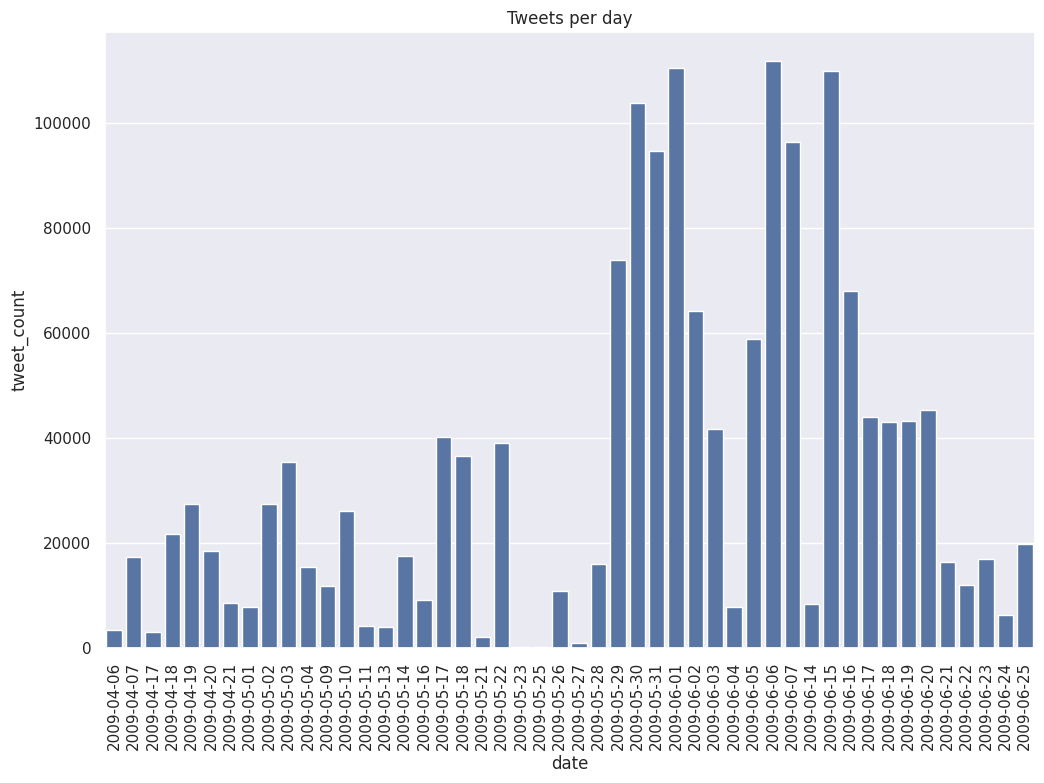

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

data = df.loc[:, ('id', 'date')].groupby(df['date'].dt.date).agg(tweet_count=('id', 'count')).reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(data=data, x='date', y='tweet_count')
plt.title(label='Tweets per day')
_ = plt.xticks(rotation=90)

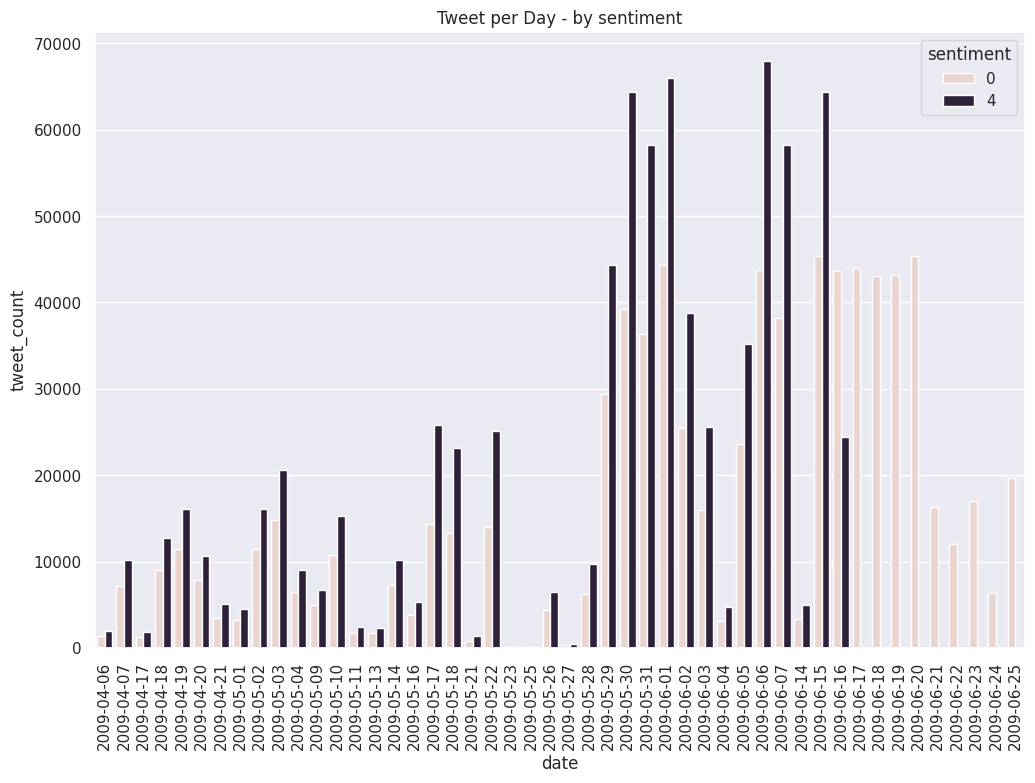

In [12]:
data = df.loc[:, ('id', 'date', 'sentiment')].groupby([df['date'].dt.date, 'sentiment']).agg(
    tweet_count=('id', 'count')).reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(data=data, x='date', y='tweet_count', hue='sentiment')
plt.title(label="Tweet per Day - by sentiment")
_ = plt.xticks(rotation=90)

#### Analyse `sentiment` Spalte

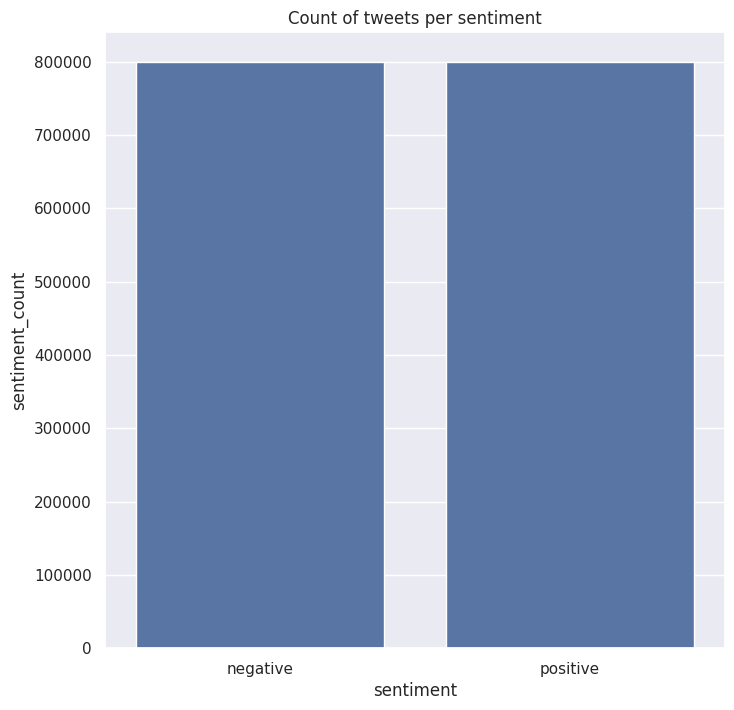

In [13]:
data = df.loc[:, ('id', 'sentiment')].groupby('sentiment').agg(sentiment_count=('id', 'count')).reset_index()
plt.figure(figsize=(8, 8))
sns.barplot(data=data, x='sentiment', y='sentiment_count')
plt.title(label='Count of tweets per sentiment')
new_labels = ['negative', 'positive']
_ = plt.xticks(ticks=range(len(new_labels)), labels=new_labels)

#### Analyse Test-Datensatz

In [14]:
df_test.loc[df_test.text.str.contains('RT')]  # enthaltene Re-Tweets

,sentiment,id,date,query,user,text
38,4,124,2009-05-16 23:48:15+00:00,stanford,imusicmash,RT @jessverr I love the nerdy Stanford human biology videos - makes me miss school. http://bit.ly/13t7NR
67,4,172,2009-05-19 16:20:46+00:00,wolfram alpha,leedscentlib,RT @mashable: Five Things Wolfram Alpha Does Better (And Vastly Different) Than Google - http://bit.ly/6nSnR
72,0,177,2009-05-20 02:39:05+00:00,nike,coreysmbpro,RT @SmartChickPDX: Was just told that Nike layoffs started today :-(
110,4,237,2009-05-27 00:39:21+00:00,goodby silverstein,suedecrush,"RT @designplay Goodby, Silverstein's new site: http://www.goodbysilverstein.com/ I enjoy it. *nice find!*"
160,2,424,2009-06-02 03:27:48+00:00,gm,hammerauto,RT @LATimesautos is now the time to buy a GM car? http://bit.ly/nRzlu
164,0,428,2009-06-02 03:32:33+00:00,dentist,LILJIZZEL,"THE DENTIST LIED! "" U WON'T FEEL ANY DISCOMORT! PROB WON'T EVEN NEED PAIN PILLS"" MAN U TWIPPIN THIS SHIT HURT!! HOW MANY PILLS CAN I TAKE!!"
197,2,558,2009-06-07 01:14:08+00:00,jquery,marcroberts,RT @jquery: The Ultimate jQuery List - http://jquerylist.com/
203,4,564,2009-06-07 03:28:08+00:00,warren buffet,Alfred04654,"RT @blknprecious1: RT GREAT @dbroos ""Someone's sitting in the shade today because someone planted a tree a long time ago.""- Warren Buffet"
209,2,570,2009-06-07 21:38:42+00:00,kindle2,aqrinc,"RT Look, Available !Amazon Kindle2 &amp; Kindle DX, Get it Here: http://short.to/87ub The Top Electronic Book Reader Period, free 2 day ship ..."
277,4,2094,2009-05-17 15:04:55+00:00,Danny Gokey,fashion_retweet,"RT @PassionModel 'American Idol' fashion: Adam Lambert tones down, Danny Gokey cute ... http://cli.gs/7JWSHV"


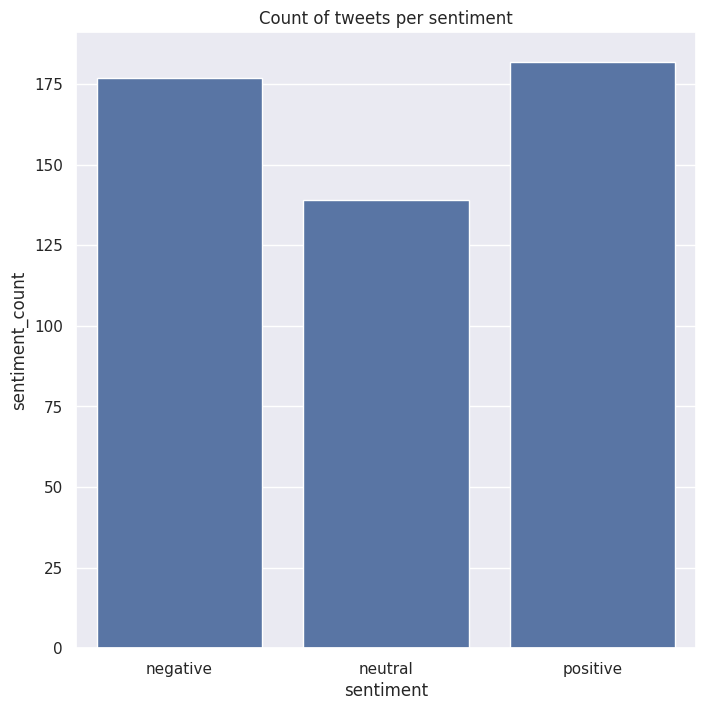

In [15]:
data = df_test.loc[:, ('id', 'sentiment')].groupby('sentiment').agg(sentiment_count=('id', 'count')).reset_index()
plt.figure(figsize=(8, 8))
sns.barplot(data=data, x='sentiment', y='sentiment_count')
plt.title(label='Count of tweets per sentiment')
new_labels = ['negative', 'neutral', 'positive']
_ = plt.xticks(ticks=range(len(new_labels)), labels=new_labels)

### Data Cleaning and Preparation

<img src="Bilder/dslc-data-cleaning-and-preparation.png" width="800" />

#### Text-Bereinigung und Tokenization

Schritte:

- Analog zum Paper werden Nennungen von Nutzern `@<user-name>`, nicht alpha-numerische Worte und URLs entfernt (s. RegEx).
- Verkürzte Wortformen werden mittels `contractions.fix()` aufgelöst.
- Der Text wird in Tokens aufgeteilt (`nltk.word_tokenize`).
- Stop-Worte werden entfernt.
- So erhaltene Token je Tweet werden in neue Spalte `tokenized_text` geschrieben.

In [16]:
import nltk
from nltk.corpus import stopwords
import re
import contractions

nltk.download('punkt_tab')

REPLACEMENT_PATTERN = re.compile("(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)")
STOP_WORDS = stopwords.words('english')


def clean_text(text: str) -> list[str]:
    text_mod = contractions.fix(text)
    text_mod = re.sub(REPLACEMENT_PATTERN, " ", text_mod).lower()

    return [w for w in nltk.word_tokenize(text_mod) if w not in STOP_WORDS]


df['tokenized_text'] = df.text.apply(lambda x: clean_text(x))

[nltk_data] Downloading package punkt_tab to /home/andi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#### Stemming/Lemmatization

Ergänzung zweier Spalten, in denen die Token (s. Spalte `tokenized_text`) auf ihre korrekte Grundform (s. `lemmatized_tokens`) bzw. eine heuristische Basisform (s. `stemmed_tokens`) geändert.

In [17]:
%%time 

from nltk.stem import WordNetLemmatizer, PorterStemmer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()


def lemmatization_of_tweet(text):
    return [lemmatizer.lemmatize(w) for w in text]


df['lemmatized_tokens'] = df.tokenized_text.apply(lambda x: lemmatization_of_tweet(x))
df.head(100)

[nltk_data] Downloading package wordnet to /home/andi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


CPU times: user 58 s, sys: 302 ms, total: 58.3 s
Wall time: 58.8 s


,sentiment,id,date,query,user,text,tokenized_text,lemmatized_tokens
0,0,1467810369,2009-04-06 22:19:45-07:00,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D","[awww, bummer, shoulda, got, david, carr, third, day]","[awww, bummer, shoulda, got, david, carr, third, day]"
1,0,1467810672,2009-04-06 22:19:49-07:00,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,"[upset, update, facebook, texting, might, cry, result, school, today, also, blah]","[upset, update, facebook, texting, might, cry, result, school, today, also, blah]"
2,0,1467810917,2009-04-06 22:19:53-07:00,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,"[dived, many, times, ball, managed, save, 50, rest, go, bounds]","[dived, many, time, ball, managed, save, 50, rest, go, bound]"
3,0,1467811184,2009-04-06 22:19:57-07:00,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,"[whole, body, feels, itchy, like, fire]","[whole, body, feel, itchy, like, fire]"
4,0,1467811193,2009-04-06 22:19:57-07:00,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.","[behaving, mad, see]","[behaving, mad, see]"
...,...,...,...,...,...,...,...,...
95,0,1467836448,2009-04-06 22:26:27-07:00,NO_QUERY,Dogbook,Strider is a sick little puppy http://apps.facebook.com/dogbook/profile/view/5248435,"[strider, sick, little, puppy]","[strider, sick, little, puppy]"
96,0,1467836500,2009-04-06 22:26:28-07:00,NO_QUERY,natalieantipas,"so rylee,grace...wana go steve's party or not?? SADLY SINCE ITS EASTER I WNT B ABLE 2 DO MUCH BUT OHH WELL.....","[rylee, grace, wana, go, steve, party, sadly, since, easter, wnt, b, able, 2, much, ohh, well]","[rylee, grace, wana, go, steve, party, sadly, since, easter, wnt, b, able, 2, much, ohh, well]"
97,0,1467836576,2009-04-06 22:26:29-07:00,NO_QUERY,timdonnelly,"hey, I actually won one of my bracket pools! Too bad it wasn't the one for money","[hey, actually, one, bracket, pools, bad, one, money]","[hey, actually, one, bracket, pool, bad, one, money]"
98,0,1467836583,2009-04-06 22:26:29-07:00,NO_QUERY,homeworld,"@stark YOU don't follow me, either and i work for you!","[follow, either, work]","[follow, either, work]"


In [18]:
%%time

stemmer = PorterStemmer()
df['stemmed_tokens'] = df.tokenized_text.apply(lambda x: [stemmer.stem(w) for w in x])
df.head(100)

CPU times: user 3min 18s, sys: 754 ms, total: 3min 19s
Wall time: 3min 20s


,sentiment,id,date,query,user,text,tokenized_text,lemmatized_tokens,stemmed_tokens
0,0,1467810369,2009-04-06 22:19:45-07:00,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D","[awww, bummer, shoulda, got, david, carr, third, day]","[awww, bummer, shoulda, got, david, carr, third, day]","[awww, bummer, shoulda, got, david, carr, third, day]"
1,0,1467810672,2009-04-06 22:19:49-07:00,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,"[upset, update, facebook, texting, might, cry, result, school, today, also, blah]","[upset, update, facebook, texting, might, cry, result, school, today, also, blah]","[upset, updat, facebook, text, might, cri, result, school, today, also, blah]"
2,0,1467810917,2009-04-06 22:19:53-07:00,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,"[dived, many, times, ball, managed, save, 50, rest, go, bounds]","[dived, many, time, ball, managed, save, 50, rest, go, bound]","[dive, mani, time, ball, manag, save, 50, rest, go, bound]"
3,0,1467811184,2009-04-06 22:19:57-07:00,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,"[whole, body, feels, itchy, like, fire]","[whole, body, feel, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
4,0,1467811193,2009-04-06 22:19:57-07:00,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.","[behaving, mad, see]","[behaving, mad, see]","[behav, mad, see]"
...,...,...,...,...,...,...,...,...,...
95,0,1467836448,2009-04-06 22:26:27-07:00,NO_QUERY,Dogbook,Strider is a sick little puppy http://apps.facebook.com/dogbook/profile/view/5248435,"[strider, sick, little, puppy]","[strider, sick, little, puppy]","[strider, sick, littl, puppi]"
96,0,1467836500,2009-04-06 22:26:28-07:00,NO_QUERY,natalieantipas,"so rylee,grace...wana go steve's party or not?? SADLY SINCE ITS EASTER I WNT B ABLE 2 DO MUCH BUT OHH WELL.....","[rylee, grace, wana, go, steve, party, sadly, since, easter, wnt, b, able, 2, much, ohh, well]","[rylee, grace, wana, go, steve, party, sadly, since, easter, wnt, b, able, 2, much, ohh, well]","[ryle, grace, wana, go, steve, parti, sadli, sinc, easter, wnt, b, abl, 2, much, ohh, well]"
97,0,1467836576,2009-04-06 22:26:29-07:00,NO_QUERY,timdonnelly,"hey, I actually won one of my bracket pools! Too bad it wasn't the one for money","[hey, actually, one, bracket, pools, bad, one, money]","[hey, actually, one, bracket, pool, bad, one, money]","[hey, actual, one, bracket, pool, bad, one, money]"
98,0,1467836583,2009-04-06 22:26:29-07:00,NO_QUERY,homeworld,"@stark YOU don't follow me, either and i work for you!","[follow, either, work]","[follow, either, work]","[follow, either, work]"


#### Speicherung des bereinigten Datensatzes

In [19]:
PREPARED_TRAIN_DATASET_FILE_PATH = DATASETS_ROOT_PATH / TRAIN_DATASET_FILE_NAME
PREPARED_TRAIN_DATASET_FILE_PATH = PREPARED_TRAIN_DATASET_FILE_PATH.with_stem(f"{PREPARED_TRAIN_DATASET_FILE_PATH.stem}-prepared")

df.to_csv(PREPARED_TRAIN_DATASET_FILE_PATH, index=False)